# Forward Pricing Analysis (V0)

Research notebook for `pricing.py`. This does **not** change agent behaviour -
`main.py`'s `should_sell()` is untouched. The goal is to understand the
engine's real pricing mechanics well enough to design a V1 forward-price
formula and a selling-cadence experiment, both proposed in the final section.

Source of truth for every number here: the installed engine at
`kaggle_environments/envs/kaggriculture/kaggriculture.py` - `pricing.py`
either calls its `market_price()` directly or reproduces the same equation
from its published constants (see `pricing.py`'s module docstring for the
exact source lines). Every function used below is cross-checked against the
live engine in `tests/test_pricing.py`.

## 1. Setup

In [1]:
import sys
import pathlib

sys.path.insert(0, str(pathlib.Path.cwd().parent))

import pricing
from pricing import MARKET_PARAMS

import matplotlib.pyplot as plt
import pandas as pd

Reusing the plotting style already validated for
`notebooks/washamba_bots_experiments_v0.ipynb` (recessive grid, no dual axes,
direct end-of-line labels), extended from 3 to 5 categorical hues - one per
plantable crop - and checked with the project's palette validator
(CVD ΔE >= 8 on every adjacent pair, normal-vision floor >= 15; the green
carries a contrast WARN against the light surface, same as the sibling
notebook, which is why every chart below direct-labels rather than relying
on the legend swatch alone).

In [2]:
SURFACE = "#fcfcfb"
INK = "#0b0b0b"
INK_MUTED = "#52514e"
GRID = "#e5e4e0"

PLANTABLE_CROPS = ["WHEAT", "CARROT", "TOMATO", "STRAWBERRY", "MELON"]
# Fixed categorical order - assigned by position, never cycled, never
# repainted if a chart later drops a crop.
CROP_COLORS = dict(zip(
    PLANTABLE_CROPS,
    ["#2a78d6", "#eb6834", "#c23b6b", "#1baf7a", "#8a5fd1"],
))

plt.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "axes.edgecolor": GRID,
    "axes.labelcolor": INK_MUTED,
    "axes.grid": True,
    "axes.axisbelow": True,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "grid.color": GRID,
    "grid.linewidth": 0.8,
    "text.color": INK,
    "xtick.color": INK_MUTED,
    "ytick.color": INK_MUTED,
    "font.size": 10,
    "figure.dpi": 110,
})


def finish(ax, title, xlabel=None, ylabel=None, legend=False):
    ax.set_title(title, fontsize=12.5, color=INK, pad=12, loc="left")
    if xlabel:
        ax.set_xlabel(xlabel)
    if ylabel:
        ax.set_ylabel(ylabel)
    if legend:
        ax.legend(frameon=False, labelcolor=INK_MUTED)
    plt.tight_layout()


def label_series_ends(ax, x_end, values_by_label, x_data_end=None, min_gap_frac=0.032, log=False):
    """Direct-label each line at its right edge, nudging labels apart when
    two or more lines end close enough together to collide (e.g. wheat/
    carrot, or several lines all converging near the price floor) - a plain
    end-of-line label positioned at the raw value is what caused illegible
    overlaps in an earlier draft of this notebook. Draws a thin leader line
    from the true data point to a nudged label so a displaced label still
    reads as belonging to its line rather than floating free."""
    import math as _math
    x_data_end = x_end if x_data_end is None else x_data_end
    if log:
        lo, hi = ax.get_ylim()
        lo, hi = _math.log10(max(lo, 1e-9)), _math.log10(hi)
    else:
        lo, hi = ax.get_ylim()
    min_gap = (hi - lo) * min_gap_frac
    order = sorted(values_by_label.items(), key=lambda kv: kv[1])
    placed = []
    for label, value in order:
        true_pos = _math.log10(max(value, 1e-9)) if log else value
        pos = true_pos
        if placed and pos - placed[-1] < min_gap:
            pos = placed[-1] + min_gap
        placed.append(pos)
        y = 10 ** pos if log else pos
        true_y = 10 ** true_pos if log else true_pos
        if abs(pos - true_pos) > 1e-9:
            ax.plot([x_data_end, x_end], [true_y, y], color=INK_MUTED,
                    linewidth=0.7, zorder=2)
        ax.text(x_end + (hi - lo) * 0.003, y, label, va="center", fontsize=9, color=INK)

## 2. Price vs inventory

`price(inv) = base +/- amp * f(|inv - I0|)`, floored at $1. Below `I0` prices
rise (scarcity); at/above `I0` they fall (glut). The five plantable crops use
different shape functions (`below_func`/`above_func`) and different `T`
(the absorption scale), so they look nothing alike away from `I0`.

Split into two charts on purpose, not one over the full range: the glut side
(2a) is where the agent actually operates - selling only ever pushes
inventory *up* for the four crops with no `BUY_PRODUCT` path (everything but
wheat), and the scarcity side (2b) turns out to be a different kind of curve
entirely (see below) that would flatten 2a to a flat line near zero if both
shared one y-axis.

### 2a. Glut side (`inv >= I0`) - the reachable region

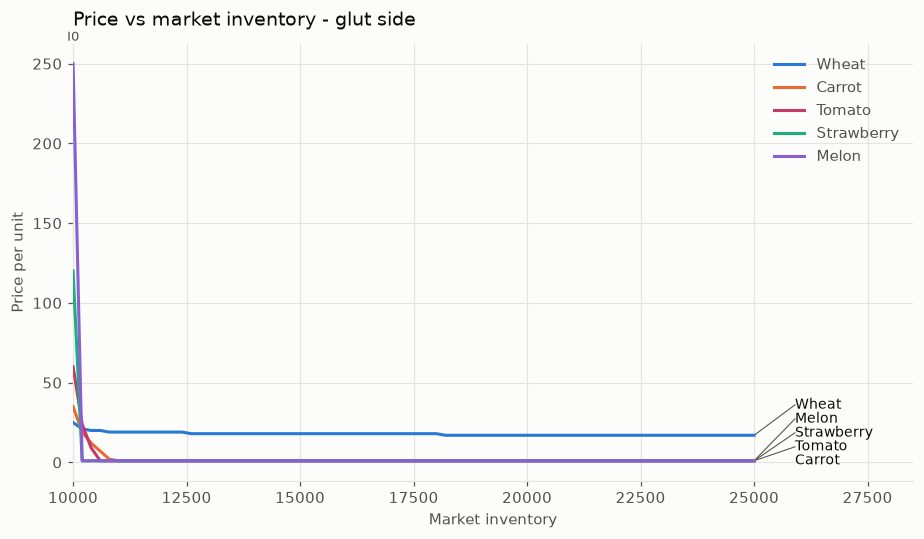

In [3]:
inventories = range(10000, 25001, 200)

fig, ax = plt.subplots(figsize=(8.5, 5))
end_values = {}
for crop in PLANTABLE_CROPS:
    prices = [pricing.market_price(crop, inv) for inv in inventories]
    ax.plot(list(inventories), prices, color=CROP_COLORS[crop], linewidth=2, label=crop.title(), zorder=3)
    end_values[crop.title()] = prices[-1]

ax.axvline(pricing.MARKET_PARAMS["WHEAT"]["I0"], color=INK_MUTED, linestyle="--", linewidth=1, zorder=1)
ax.text(pricing.MARKET_PARAMS["WHEAT"]["I0"], ax.get_ylim()[1], "I0",
        ha="center", va="bottom", fontsize=8.5, color=INK_MUTED)

ax.set_xlim(10000, 28500)
label_series_ends(ax, 25900, end_values, x_data_end=25000)
finish(ax, "Price vs market inventory - glut side",
       xlabel="Market inventory", ylabel="Price per unit", legend=True)
plt.show()

Melon and strawberry (the two premium crops) fall off fastest above `I0` -
melon uses `above_func="sq"` with `above_target=3.60`, the steepest curve of
the five. Wheat and carrot are comparatively flat, which is exactly why
`CLAUDE.md` describes wheat as absorbing volume the fragile crops can't.

### 2b. Scarcity side (`inv < I0`) - mostly unreachable in play

Log scale on price: `below_func="hinge"` (carrot, tomato) is deliberately
explosive once inventory drops much past its own `T` below `I0` (the engine's
own comment: it "spikes once x passes T"), while `sqrt`/`log` (wheat,
strawberry, melon) stay bounded even at the same distance. On a shared
linear axis the hinge crops would blow out to 6 figures and flatten
everything else to a line at zero - which is what an earlier, single-chart
version of this section actually looked like before it was split.

**Reachability matters here**: only `WHEAT`/`FERTILIZER` have a `BUY_PRODUCT`
path, so the other four crops can *only* lose inventory to town demand -
roughly 1-2 units/turn at most (section 4). Draining 1,500 units this way
would take far more turns than a 720-turn season has, so the far-left edge
of this chart is a property of the formula, not a state the market will
actually reach.

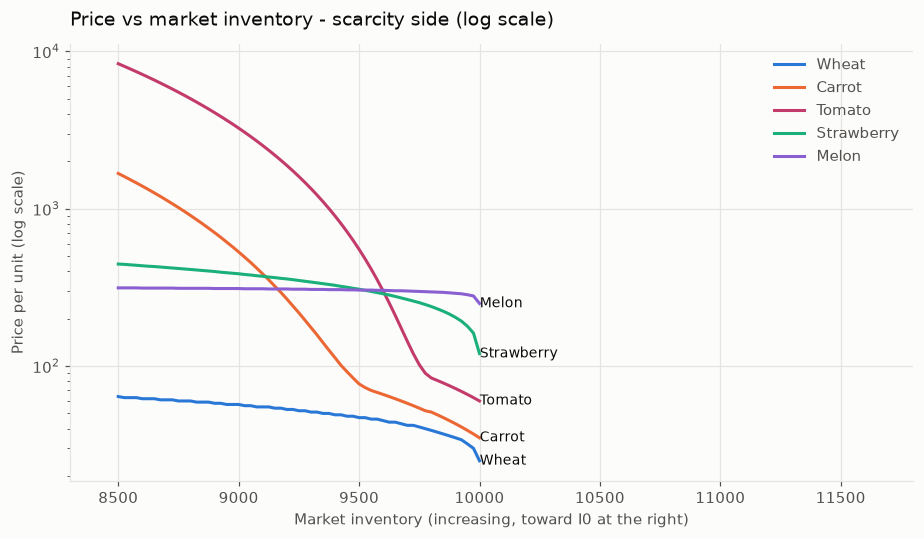

In [4]:
scarce_inventories = range(8500, 10001, 25)

fig, ax = plt.subplots(figsize=(8.5, 5))
end_values = {}
for crop in PLANTABLE_CROPS:
    prices = [pricing.market_price(crop, inv) for inv in scarce_inventories]
    ax.plot(list(scarce_inventories), prices, color=CROP_COLORS[crop], linewidth=2, label=crop.title(), zorder=3)
    end_values[crop.title()] = prices[-1]

ax.set_yscale("log")
ax.set_xlim(8300, 11800)
label_series_ends(ax, 10001, end_values, x_data_end=10000, log=True)
finish(ax, "Price vs market inventory - scarcity side (log scale)",
       xlabel="Market inventory (increasing, toward I0 at the right)", ylabel="Price per unit (log scale)", legend=True)
plt.show()

## 3. Marginal price impact of one additional unit

`price(inv) - price(inv + 1)` at a given starting point - what does *the next
single unit* cost us in price, right now. This is a local slope, not the
average price of a whole order (see section 5 for that).

In [5]:
marginal_rows = []
for crop in PLANTABLE_CROPS:
    I0 = MARKET_PARAMS[crop]["I0"]
    for offset, label in [(-2000, "scarce (I0-2000)"), (0, "baseline (I0)"),
                          (2000, "mild glut (I0+2000)"), (8000, "heavy glut (I0+8000)")]:
        inv = I0 + offset
        marginal = pricing.market_price(crop, inv) - pricing.market_price(crop, inv + 1)
        marginal_rows.append({"crop": crop, "market state": label, "marginal $/unit": marginal})

pd.DataFrame(marginal_rows).pivot(index="crop", columns="market state", values="marginal $/unit")[
    ["scarce (I0-2000)", "baseline (I0)", "mild glut (I0+2000)", "heavy glut (I0+8000)"]
]

market state,scarce (I0-2000),baseline (I0),mild glut (I0+2000),heavy glut (I0+8000)
crop,,,,
CARROT,5,1,0,0
MELON,0,0,0,0
STRAWBERRY,0,2,0,0
TOMATO,17,3,0,0
WHEAT,0,1,0,0


The marginal cost of one more unit is close to zero at baseline for every
crop, and only becomes material once a crop is already in a glut - and even
then it varies by an order of magnitude across crops. A per-product
sell-quantity cap tuned for melon is not the right cap for wheat.

## 4. Price recovery over time

Push each crop into a mid-size glut (`our_supply=30` at once, roughly a
single big-harvest sell order), then let town demand alone run for several
days with **no new shops assumed to unlock** (a simplifying, slightly
optimistic assumption spelled out in `pricing.py`'s `apply_town_demand`
docstring - real recovery is at least this fast, since any additional shop
unlock only adds more demand).

/var/folders/0p/dc6dwtl15sx7dm16_ycrfr600000gn/T/ipykernel_35830/1124681415.py:40: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False, labelcolor=INK_MUTED)


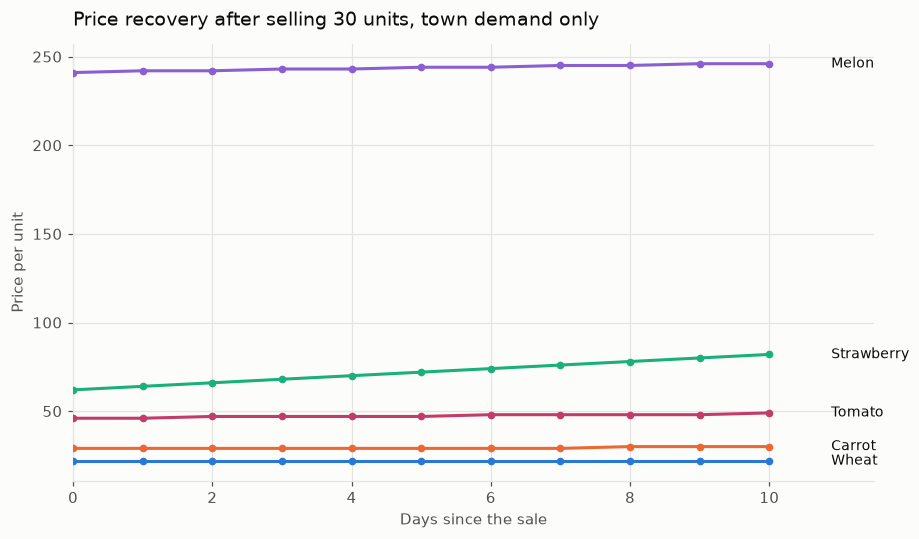

In [6]:
TURNS_PER_DAY = 24
days = list(range(0, 11))

fig, ax = plt.subplots(figsize=(8.5, 5))
end_values = {}
for crop in PLANTABLE_CROPS:
    I0 = MARKET_PARAMS[crop]["I0"]
    recovery = [
        pricing.estimate_future_price(
            crop, I0, turns_ahead=day * TURNS_PER_DAY,
            our_pipeline_supply=30, unlocked_shops=(),
        )["future_price"]
        for day in days
    ]
    ax.plot(days, recovery, color=CROP_COLORS[crop], linewidth=2, marker="o", markersize=4, zorder=3)
    end_values[crop.title()] = recovery[-1]

ax.set_xlim(0, 11.5)
label_series_ends(ax, 10.15, end_values, x_data_end=10)
finish(ax, "Price recovery after selling 30 units, town demand only",
       xlabel="Days since the sale", ylabel="Price per unit", legend=True)
plt.show()

Town demand drains roughly 1-2 units/day per crop with nothing unlocked
(just the Town Center's flat 1/day) - glacial next to a 30-unit sale. Wheat
and carrot, which barely moved in section 2, recover almost immediately;
melon and strawberry take days to claw back toward base price. **A crashed
premium-crop market does not meaningfully recover within a single season's
remaining days** unless shops unlock and add real demand on top.

## 5. Crop differences

The engine parameters behind sections 2-4, side by side.

In [7]:
pd.DataFrame(MARKET_PARAMS).T.loc[PLANTABLE_CROPS]

,base,I0,T,below_func,below_target,above_func,above_target
WHEAT,25,10000,400,sqrt,0.8,log,0.2
CARROT,35,10000,450,hinge,1.0,sqrt,0.7
TOMATO,60,10000,200,hinge,0.4,sqrt,0.6
STRAWBERRY,120,10000,100,sqrt,0.7,linear,1.6
MELON,250,10000,300,log,0.2,sq,3.6


## 6. Effect of selling 1, 5, 10, 25, 50 units

Average realised price per unit for a single order of increasing size,
starting from baseline inventory (`I0`) - this is what actually lands in the
bank per unit sold, not the spot price before the order.

In [8]:
quantities = [1, 5, 10, 25, 50]
sell_rows = []
for crop in PLANTABLE_CROPS:
    I0 = MARKET_PARAMS[crop]["I0"]
    for qty in quantities:
        path = pricing.price_path_for_sale(crop, I0, qty)
        sell_rows.append({
            "crop": crop, "quantity": qty,
            "avg price/unit": sum(path["prices"]) / qty,
            "last unit price": path["prices"][-1],
        })

sell_df = pd.DataFrame(sell_rows)
sell_df.pivot(index="crop", columns="quantity", values="avg price/unit").loc[PLANTABLE_CROPS]

quantity,1,5,10,25,50
crop,,,,,
WHEAT,25.0,24.2,23.7,23.08,22.54
CARROT,35.0,33.6,32.8,31.28,29.64
TOMATO,60.0,56.8,55.0,51.80,48.22
STRAWBERRY,120.0,116.0,111.3,96.96,72.96
MELON,250.0,250.0,249.8,248.08,241.96


/var/folders/0p/dc6dwtl15sx7dm16_ycrfr600000gn/T/ipykernel_35830/1124681415.py:40: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False, labelcolor=INK_MUTED)


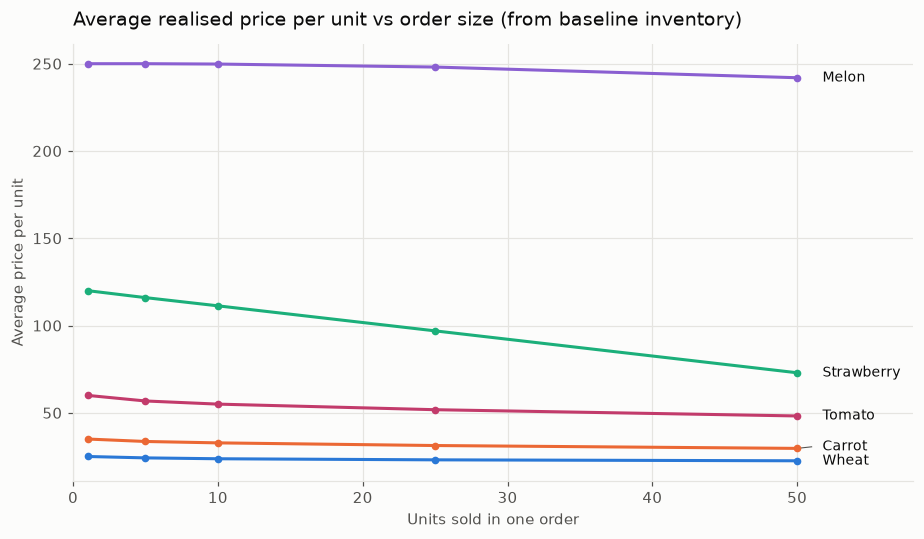

In [9]:
fig, ax = plt.subplots(figsize=(8.5, 5))
end_values = {}
for crop in PLANTABLE_CROPS:
    subset = sell_df[sell_df["crop"] == crop]
    ax.plot(subset["quantity"], subset["avg price/unit"], color=CROP_COLORS[crop],
            linewidth=2, marker="o", markersize=4, zorder=3)
    end_values[crop.title()] = subset["avg price/unit"].iloc[-1]

ax.set_xlim(0, 58)
label_series_ends(ax, 51, end_values, x_data_end=50)
finish(ax, "Average realised price per unit vs order size (from baseline inventory)",
       xlabel="Units sold in one order", ylabel="Average price per unit", legend=True)
plt.show()

Wheat and carrot barely discount even at 50 units in one order. Melon and
strawberry both show a visible knee well under 50 - consistent with
`main.py`'s existing `MAX_SELL_PER_TURN` caps (10 for strawberry, 15 for
melon), which this data broadly supports rather than contradicts.

## 7. Effect of our own expected pipeline supply

How much does *already knowing* we'll harvest N more units of a crop before
we sell change the price we should expect at sale time - separate from
whatever the market does on its own between now and then.

/var/folders/0p/dc6dwtl15sx7dm16_ycrfr600000gn/T/ipykernel_35830/1124681415.py:40: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False, labelcolor=INK_MUTED)


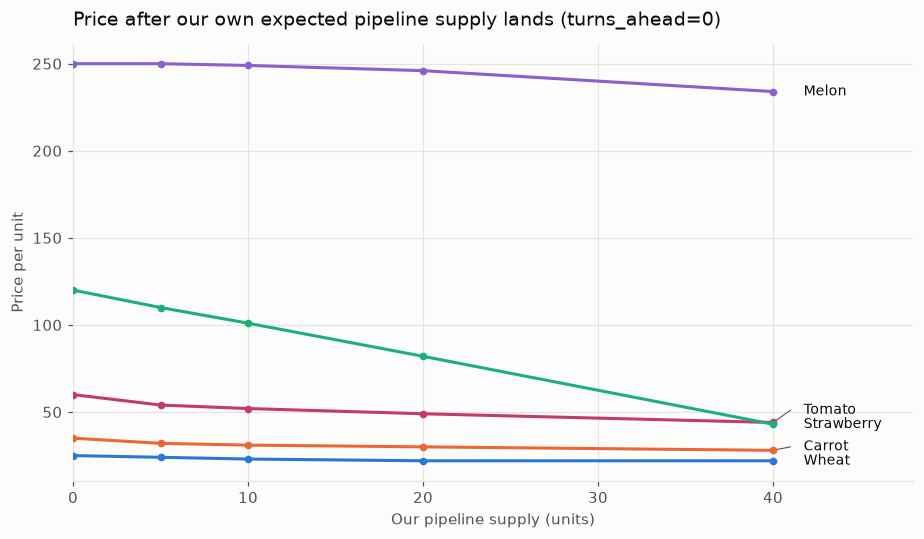

In [10]:
pipeline_sizes = [0, 5, 10, 20, 40]

fig, ax = plt.subplots(figsize=(8.5, 5))
end_values = {}
for crop in PLANTABLE_CROPS:
    I0 = MARKET_PARAMS[crop]["I0"]
    prices = [
        pricing.estimate_future_price(crop, I0, turns_ahead=0, our_pipeline_supply=n)["future_price"]
        for n in pipeline_sizes
    ]
    ax.plot(pipeline_sizes, prices, color=CROP_COLORS[crop], linewidth=2, marker="o", markersize=4, zorder=3)
    end_values[crop.title()] = prices[-1]

ax.set_xlim(0, 48)
label_series_ends(ax, 41, end_values, x_data_end=40)
finish(ax, "Price after our own expected pipeline supply lands (turns_ahead=0)",
       xlabel="Our pipeline supply (units)", ylabel="Price per unit", legend=True)
plt.show()

This is the mechanism `choose_crop`'s existing self-supply discount already
leans on (see `CLAUDE.md`'s "price in our own incoming supply" entry) - this
chart is the first direct look at the actual price curve behind that
discount rather than the discount formula's own shape.

## 8. Effect of an assumed opponent supply

Same question, but for supply we don't control: if an opponent sells N units
of the same crop into the same market before our sale lands, on top of our
own pipeline. Modelled as landing at the same point as our supply (see
`pricing.py`'s `estimate_future_price` docstring for why - it's a
deliberately simple first-version assumption, not a claim about real
opponent timing).

/var/folders/0p/dc6dwtl15sx7dm16_ycrfr600000gn/T/ipykernel_35830/1124681415.py:40: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False, labelcolor=INK_MUTED)


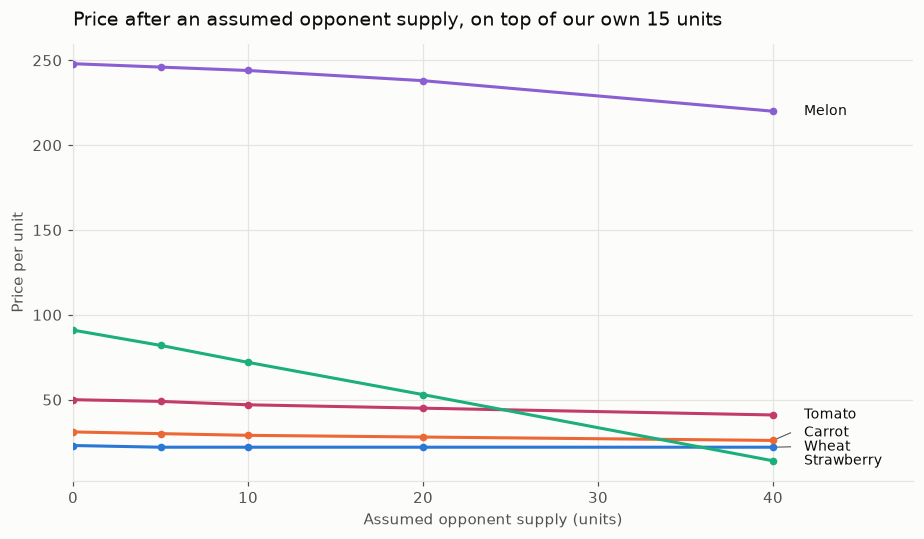

In [11]:
opponent_sizes = [0, 5, 10, 20, 40]
OUR_FIXED_SUPPLY = 15

fig, ax = plt.subplots(figsize=(8.5, 5))
end_values = {}
for crop in PLANTABLE_CROPS:
    I0 = MARKET_PARAMS[crop]["I0"]
    prices = [
        pricing.estimate_future_price(
            crop, I0, turns_ahead=0,
            our_pipeline_supply=OUR_FIXED_SUPPLY, opponent_pipeline_supply=n,
        )["future_price"]
        for n in opponent_sizes
    ]
    ax.plot(opponent_sizes, prices, color=CROP_COLORS[crop], linewidth=2, marker="o", markersize=4, zorder=3)
    end_values[crop.title()] = prices[-1]

ax.set_xlim(0, 48)
label_series_ends(ax, 41, end_values, x_data_end=40)
finish(ax, f"Price after an assumed opponent supply, on top of our own {OUR_FIXED_SUPPLY} units",
       xlabel="Assumed opponent supply (units)", ylabel="Price per unit", legend=True)
plt.show()

This is exactly the mechanism `CLAUDE.md` already names as the reason local
benchmarks over-flatter the agent: `pass`/`random`/`starter` never sell, so
this axis is always zero against them, and self-play is the only local setup
where it isn't. A real ladder opponent sits somewhere on this curve, not at
the left edge.

## 9. Findings

- **Price vs inventory is crop-specific, not a single curve** - melon and
  strawberry crash an order of magnitude faster than wheat and carrot per
  unit oversupplied (section 2), because `above_func`/`above_target` differ
  per crop, not just `T`.
- **Marginal cost per unit is near zero at baseline for every crop** and only
  becomes material inside an existing glut (section 3) - there's no
  meaningful penalty for the first few units of an order regardless of crop.
- **Town demand alone recovers a glut slowly** - roughly 1-2 units/day with no
  shops unlocked (section 4). A season has 30 days; a melon/strawberry glut
  from a big harvest will not fully heal in the time remaining after roughly
  the two-thirds mark of the season.
- **Existing `MAX_SELL_PER_TURN` caps are broadly the right shape** - the
  order-size sweep (section 6) shows a visible discount knee under 50 units
  for melon/strawberry and almost none for wheat/carrot, consistent with the
  current 15/10 caps rather than contradicting them.
- **Our own pipeline supply and an assumed opponent's have the same
  mechanical effect on price** (sections 7-8) - the market doesn't know or
  care whose harvest it is. Only the sign of *who profits* differs.

## 10. What's still unavailable

- **No visibility into the opponent's actual shed or planting plan.** Section
  8's opponent-supply axis is a swept assumption, not an estimate from real
  data - `obs["private"]` never exposes the opponent's shed
  (`CLAUDE.md`: "opponent's shed is never visible").
- **Future shop unlocks are stochastic and not modelled.** `apply_town_demand`
  freezes `unlocked_shops` at whatever's passed in; a real multi-day forecast
  should get worse (more town demand, price recovers faster than shown here)
  as the season progresses, not better.
- **`our_pipeline_supply` and `opponent_pipeline_supply` both land instantly
  at `turns_ahead=0`** rather than spread across the window before harvest -
  a simplifying choice, not a measured schedule of when units actually
  arrive.
- **No cross-check yet against a live ladder opponent's real selling
  behaviour** - self-play (both sides running our own code) is the closest
  local proxy, but it isn't a different strategy competing for the same
  market.

## 11. Proposed V1 forward-price formula (proposal only - not implemented)

Score a crop at planting time by its price **at expected harvest**, not spot
price, using `estimate_future_price` with:

- `turns_ahead` = the crop's `first_yield_day` (or the specific harvest day
  being planned for) minus the current day, in turns,
- `our_pipeline_supply` = everything already planted/growing of that crop
  plus what's already in the shed (the same total `choose_crop`'s existing
  self-supply discount already sums, per `CLAUDE.md`),
- `opponent_pipeline_supply` = a small fixed assumption (e.g. one
  opponent-farm's worth of the same crop) rather than zero, so scoring stops
  implicitly assuming a `pass`-like opponent - open question: what constant is
  defensible without opponent shed visibility (see section 10),
- `unlocked_shops` = `obs["town"]["unlocked_shops"]` at call time (freezing
  future unlocks is optimistic per section 10, so this likely
  underestimates future demand, i.e. underestimates recovery speed - a safe
  direction for a first version to be wrong in).

This replaces spot price in `choose_crop`'s scoring with `future_price`, still
combined with the crop's yield/day economics the same way spot price is used
today - a plug-in replacement for one term, not a rewrite of the scoring
function. **Not implemented in this notebook or in `main.py`** - proposal
for the next experiment, to go through `docs/EXPERIMENT_WORKFLOW.md` (one
change at a time, self-play + seeded batch, compare against the frozen V1
control) before it's accepted.

## 12. Proposed selling cadence experiment (proposal only - not implemented)

Section 6 suggests the current fixed `MAX_SELL_PER_TURN` caps (melon 15,
strawberry 10) are roughly right in shape but were not derived from this
data - they were tuned by hand. Proposed experiment, one variable at a time
per `docs/EXPERIMENT_WORKFLOW.md`:

1. **Define the metric first**: average realised price per unit sold for
   melon and strawberry specifically (not overall bank), since section 6
   shows only those two crops have a meaningful order-size knee.
2. **Treatment**: replace the fixed per-turn cap with
   `recommend_sell_quantity(item, inventory, shed_quantity,
   min_acceptable_price=<current SELL_PRICE_THRESHOLDS value>)` from
   `pricing.py`, so the cap is derived from the live price path each turn
   instead of a constant - control is the current fixed-cap `should_sell()`,
   unchanged, per V1 in `docs/CHECKPOINTS.md`.
3. **Hold everything else fixed** - crop selection, planting, hiring, and the
   threshold values themselves stay exactly as they are; only how many units
   clear per turn changes.
4. **Measure**: self-play mean/stdev (the number that predicts the ladder,
   per `CONTRIBUTING.md`), plus the average-realised-price metric from step
   1, plus shed occupancy over time (does a smarter cap leave more stock
   sitting unsold near season end, risking the liquidation cliff
   `CLAUDE.md` already documents).
5. **Accept/reject** per `docs/EXPERIMENT_WORKFLOW.md` - a bank delta inside
   stdev is not a win even if the targeted metric (avg realised price) moves,
   and vice versa.